In [1]:
import numba as nb
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation as mad

In [2]:
# OLS STUFF

def get_prediction_error(res, spectra):
    '''Get the error on the predicted UTC discrepancy given residual matrix'''
    A = np.column_stack((spectra, np.ones(len(spectra))))
    N = np.cov(res)
    print(N)

    if res.ndim >1:
        v1 = np.linalg.inv(A.T@np.linalg.inv(N)@A)
    else:
        v1 = N*np.linalg.inv(A.T@A)

    return A@v1@A.T


@nb.njit()
def symmetrize(A):
    """
    Symmetrize a matrix
    """
    nr, nc = A.shape
    for i in range(nr):
        for j in range(i, nc):
            A[j, i] = A[i, j]

def get_grammian(nant):
    """
    Determine grammian for nant anntena.
    """
    nbl = (nant - 1) * nant // 2
    Ag = np.zeros((nbl, nant - 1), dtype="float64")
    b = 0
    for i in range(nant):
        for j in range(i + 1, nant):
            # print(i,j)
            if i == 0:
                Ag[b, j - 1] = -1
            else:
                Ag[b, i - 1] = 1
                Ag[b, j - 1] = -1
            b += 1
    return Ag

def get_AtA_Atd(data, Ag, noise_var, nu, nant, nfreq, ntime, fit_constant=True):
    """
    Determine both A^T A and A^T d for OLS fitting.

    Parameters
    ----------
    data : np.ndarray shape (ntimes, nchans, nblines)
        Data input. Different form than usual, as in column-major ordering
    Ag : 
        XXXX
    noise_var : 
        XXXX
    nu : 
        XXXX
    nant : int
        Number of antenna in entire system (including reference antenna)
    nfreqs : int
        Number of channels
    ntime : int
        Number of time samples we are fitting over
    fit_constant : bool
        XXXX
    """
    two_pi = 2*np.pi
    # number of params is all non ref ants for all times
    nparam = (nant - 1) * ntime
    # if fit constants, one fixed angle offset for each non-ref antenna
    if fit_constant:
        nparam += nant - 1
    # determine total number of baselines
    nbl = (nant - 1) * nant // 2
    # determine number of datapoints per time sample
    npertime = nfreq * nbl
    print("n pertime", npertime)
    # make empty arrays of correct shape
    myAtA = np.zeros((nparam, nparam), dtype="float64")
    myAtd = np.zeros((nparam,), dtype="float64")
    # get sum of 2*pi*nus, and also squared version
    Snu2 = np.sum(nu**2) * two_pi**2
    Snu = np.sum(nu) * two_pi
    print("Snu", Snu, "Snu2", Snu2)
    #make block size
    bs = nant - 1 
    # print("nant", nant, "nbl", nbl, "ntime", ntime, "nfreq", nfreq, "bs", bs)
    
    for i in range(ntime):
        # whiten A
        Agw = Ag / noise_var[i, :][:, None]
        myAtA[i * bs : (i + 1) * bs, i * bs : (i + 1) * bs] = Ag.T @ Agw * Snu2
        if fit_constant:
            myAtA[i * bs : (i + 1) * bs, ntime * bs :] = Ag.T @ Agw * Snu
            myAtA[ntime * bs :, ntime * bs :] += Ag.T @ Agw * nfreq
        for j in range(nfreq):
            idx = i * npertime + j * nbl
            vec = Agw.T @ data[i, j, :]
            myAtd[i * bs : (i + 1) * bs] += two_pi * nu[j] * vec
            if fit_constant:
                myAtd[-bs:] += vec
    symmetrize(myAtA)
    return myAtA, myAtd



def get_AtA_Atd2(data, Ag, noise_var, nu, nant, nfreq, ntime):
    two_pi = 2*np.pi

    # number of params is all non-ref ants for all times, for both tau and theta
    bs = nant - 1
    nparam = 2 * bs * ntime

    # determine total number of baselines
    nbl = (nant - 1) * nant // 2

    # number of datapoints per time sample
    npertime = nfreq * nbl
    print("n pertime", npertime)

    # arrays
    myAtA = np.zeros((nparam, nparam), dtype="float64")
    myAtd = np.zeros((nparam,), dtype="float64")

    # frequency sums
    Snu2 = np.sum(nu**2) * two_pi**2
    Snu = np.sum(nu) * two_pi
    print("Snu", Snu, "Snu2", Snu2)

    # loop over times
    for i in range(ntime):

        # whitened baseline matrix
        Agw = Ag / noise_var[i, :][:, None]

        # indices for this time
        tau_idx = slice(i*bs, (i+1)*bs)
        theta_idx = slice(ntime*bs + i*bs, ntime*bs + (i+1)*bs)

        # antenna Gram matrix
        G = Ag.T @ Agw

        # tau-tau block
        myAtA[tau_idx, tau_idx] = G * Snu2

        # tau-theta block
        myAtA[tau_idx, theta_idx] = G * Snu

        # theta-tau block (symmetry)
        myAtA[theta_idx, tau_idx] = G * Snu

        # theta-theta block
        myAtA[theta_idx, theta_idx] = G * nfreq


        # A^T d terms
        for j in range(nfreq):

            # baseline index for this frequency/time
            idx = i*npertime + j*nbl

            # projection of baseline data onto antenna parameters
            vec = Agw.T @ data[i,j,:]

            # delay contribution
            myAtd[tau_idx] += two_pi * nu[j] * vec

            # phase offset contribution
            myAtd[theta_idx] += vec

    return myAtA, myAtd

In [3]:
#CXCORR function
def get_coarse_xcorr(f1,f2,chans=None):
    """ Get coarse xcorr of each channel of two channelized timestreams.
    The xcorr is 0-padded, so length of output is twice the original length (shape[0]).
    
    Parameters
    ----------
    f1, f2 : ndarray of complex64
        First and second timestreams. Both n_spectrum x n_channel complex array.
    chans: tuple of int
        Channels (columns) of f1 and f2 that should be correlated.
    
    Returns
    -------
    ndarray of complex128
        xcorr of each channel's timestream. 2*n_spectrum x n_channel complex array.
    """
    if chans is None:
        chans = np.arange(f1.shape[1])
    Nsmall=f1.shape[0]
    print("Shape of passed channelized timestream =", f1.shape)
    xcorr=np.zeros((len(chans),2*Nsmall),dtype='complex128')
    win=np.hamming(2*Nsmall)
    wt = np.zeros(2*Nsmall)
    wt[:Nsmall] = 1
    n_avg = np.fft.irfft(np.fft.rfft(wt)*np.conj(np.fft.rfft(wt)))
    for i,chan in enumerate(chans):
        print("processing chan", chan)
#         p0=np.zeros(2*Nsmall,dtype='complex128')
#         p1=np.zeros(2*Nsmall,dtype='complex128')
#         p0[:Nsmall]=f1[:Nsmall,chan].flatten()
#         p1[:Nsmall]=f2[:Nsmall,chan].flatten()
#         xcorr[:,i]=np.fft.ifft(np.fft.fft(p0)*np.conj(np.fft.fft(p1)))
        xcorr[i, :] = np.fft.ifft(
                        np.fft.fft(np.hstack([f1[:, chan].flatten(), np.zeros(Nsmall, dtype="complex128")]))
                        * np.conj(
                            np.fft.fft(np.hstack([f2[:, chan].flatten(), np.zeros(Nsmall, dtype="complex128")]))
                        )
                    )
#         xcorr[Nsmall-bb:Nsmall+bb,i]=np.nan
        xcorr[i, :]=xcorr[i, :]/n_avg/4096
    print(xcorr.shape)
    
    return np.ma.masked_invalid(xcorr)

    

#make visibilities with osamp1
def get_vis(d1, d2, nspec, nchans, blocksize, start=0, shift=0):
    nblocks = nspec//blocksize
    vis = np.zeros((nblocks, nchans), dtype="complex128")
    print("nblocks", nblocks)
    for i in range(nblocks):
        ix = start * blocksize + i * blocksize
        y1 = d1[ix : ix + blocksize, :]
        y2 = d2[ix + shift : ix + shift + blocksize, :]
        xc_small = y1 * np.conj(y2)
        vis[i, :] = np.mean(xc_small, axis=0)
    return vis  

In [4]:
#PLOTTING STUFF
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Baseband Data

In [5]:
data_loc_single = "/project/rrg-sievers/mohanagr/albatros_test_data/spectra_1830_1840_4096_24000_0.05_1.00e-10_20260408_192234.npz"
data_loc_multi = "/scratch/thomasb/mohan/spectra_multicarrier_1830_1890_4096_24000_0.05_1.00e-10_20260706_180425.npz"
with np.load(data_loc_multi) as f:
    spec1 = f["spectra1"]
    spec2 = f["spectra2"]     
    delays = f["delays"]*4

In [6]:
print(spec1.shape)
print(spec2.shape)
print(delays.shape)

(12000000, 60)
(12000000, 60)
(12000000,)


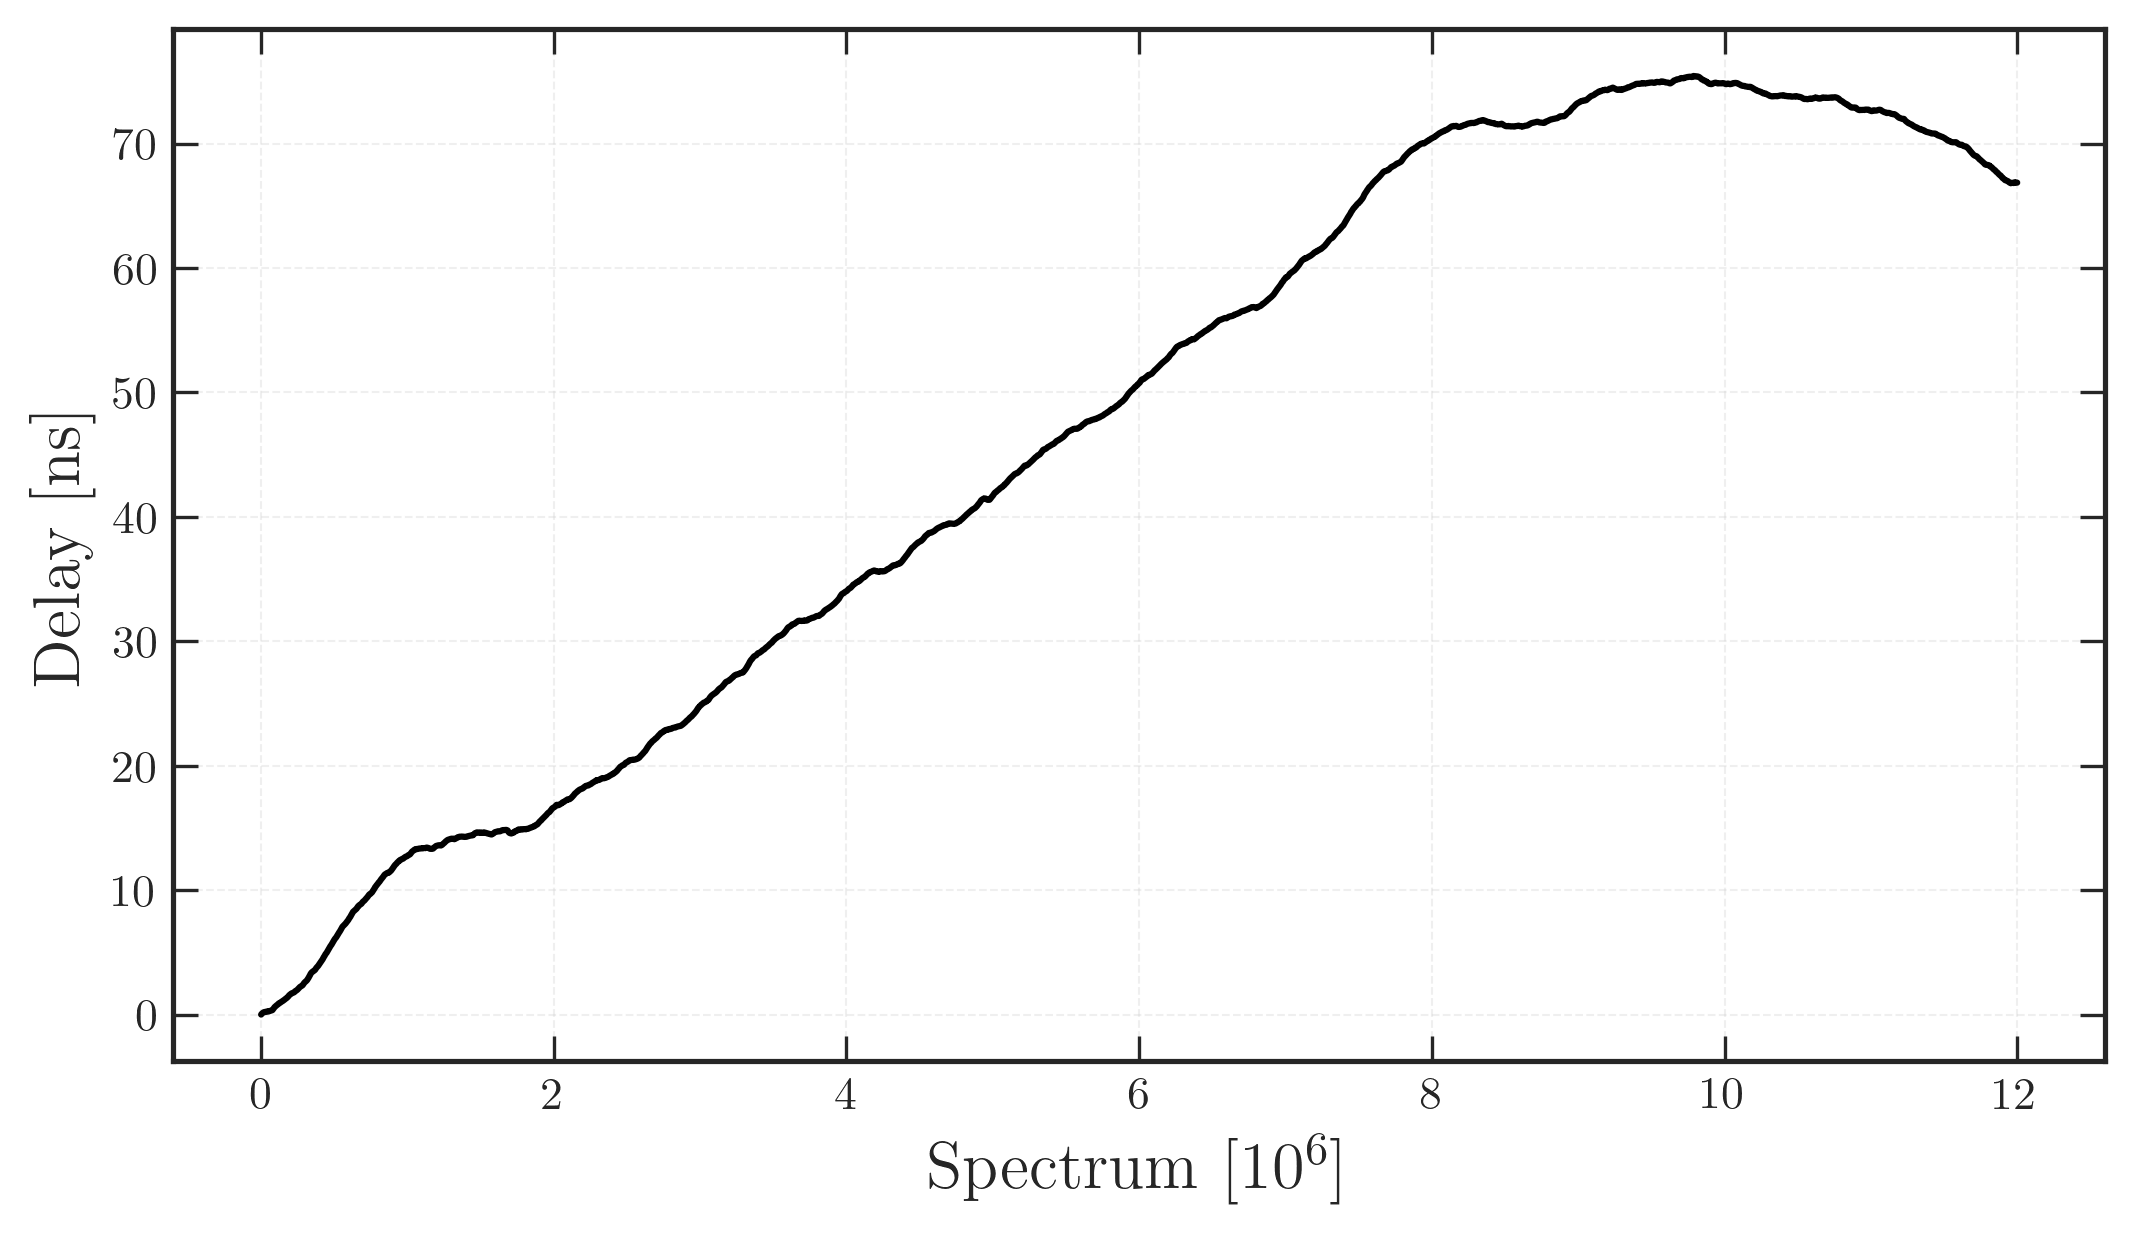

In [7]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(np.arange(len(delays))/1e6, delays,color='k',lw=1.5,)
T_ACCLEN = 4096/250e6
ax.set_xlabel(r"Spectrum [$10^6$]")
ax.set_ylabel(r"Delay [ns]")
#ax.set_title(r"Simulated Delay vs. Time")
ax.tick_params(direction='in',top=True,right=True)

# Optional: light grid for readability
ax.grid(alpha=0.3,linestyle='--',linewidth=0.5)

plt.savefig("/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/sim_clock.png", bbox_inches="tight", dpi=300)
plt.show()

## Get the CXCORR

In [12]:
#chan_slice = [3, 4, 5]
chan_slice = [4, 15, 25, 35, 45, 55]

In [13]:
#take the cxcorr but only for channels that have actual signal in them
cxcorr = get_coarse_xcorr(spec1,spec2,chan_slice)
cxcorr = np.fft.fftshift(cxcorr,axes=1)
print(cxcorr.shape)

Shape of passed channelized timestream = (12000000, 60)
processing chan 4
processing chan 15
processing chan 25
processing chan 35
processing chan 45
processing chan 55
(6, 24000000)
(6, 24000000)


Plot some stuff

-5
-5
-5
-5
-5
-5


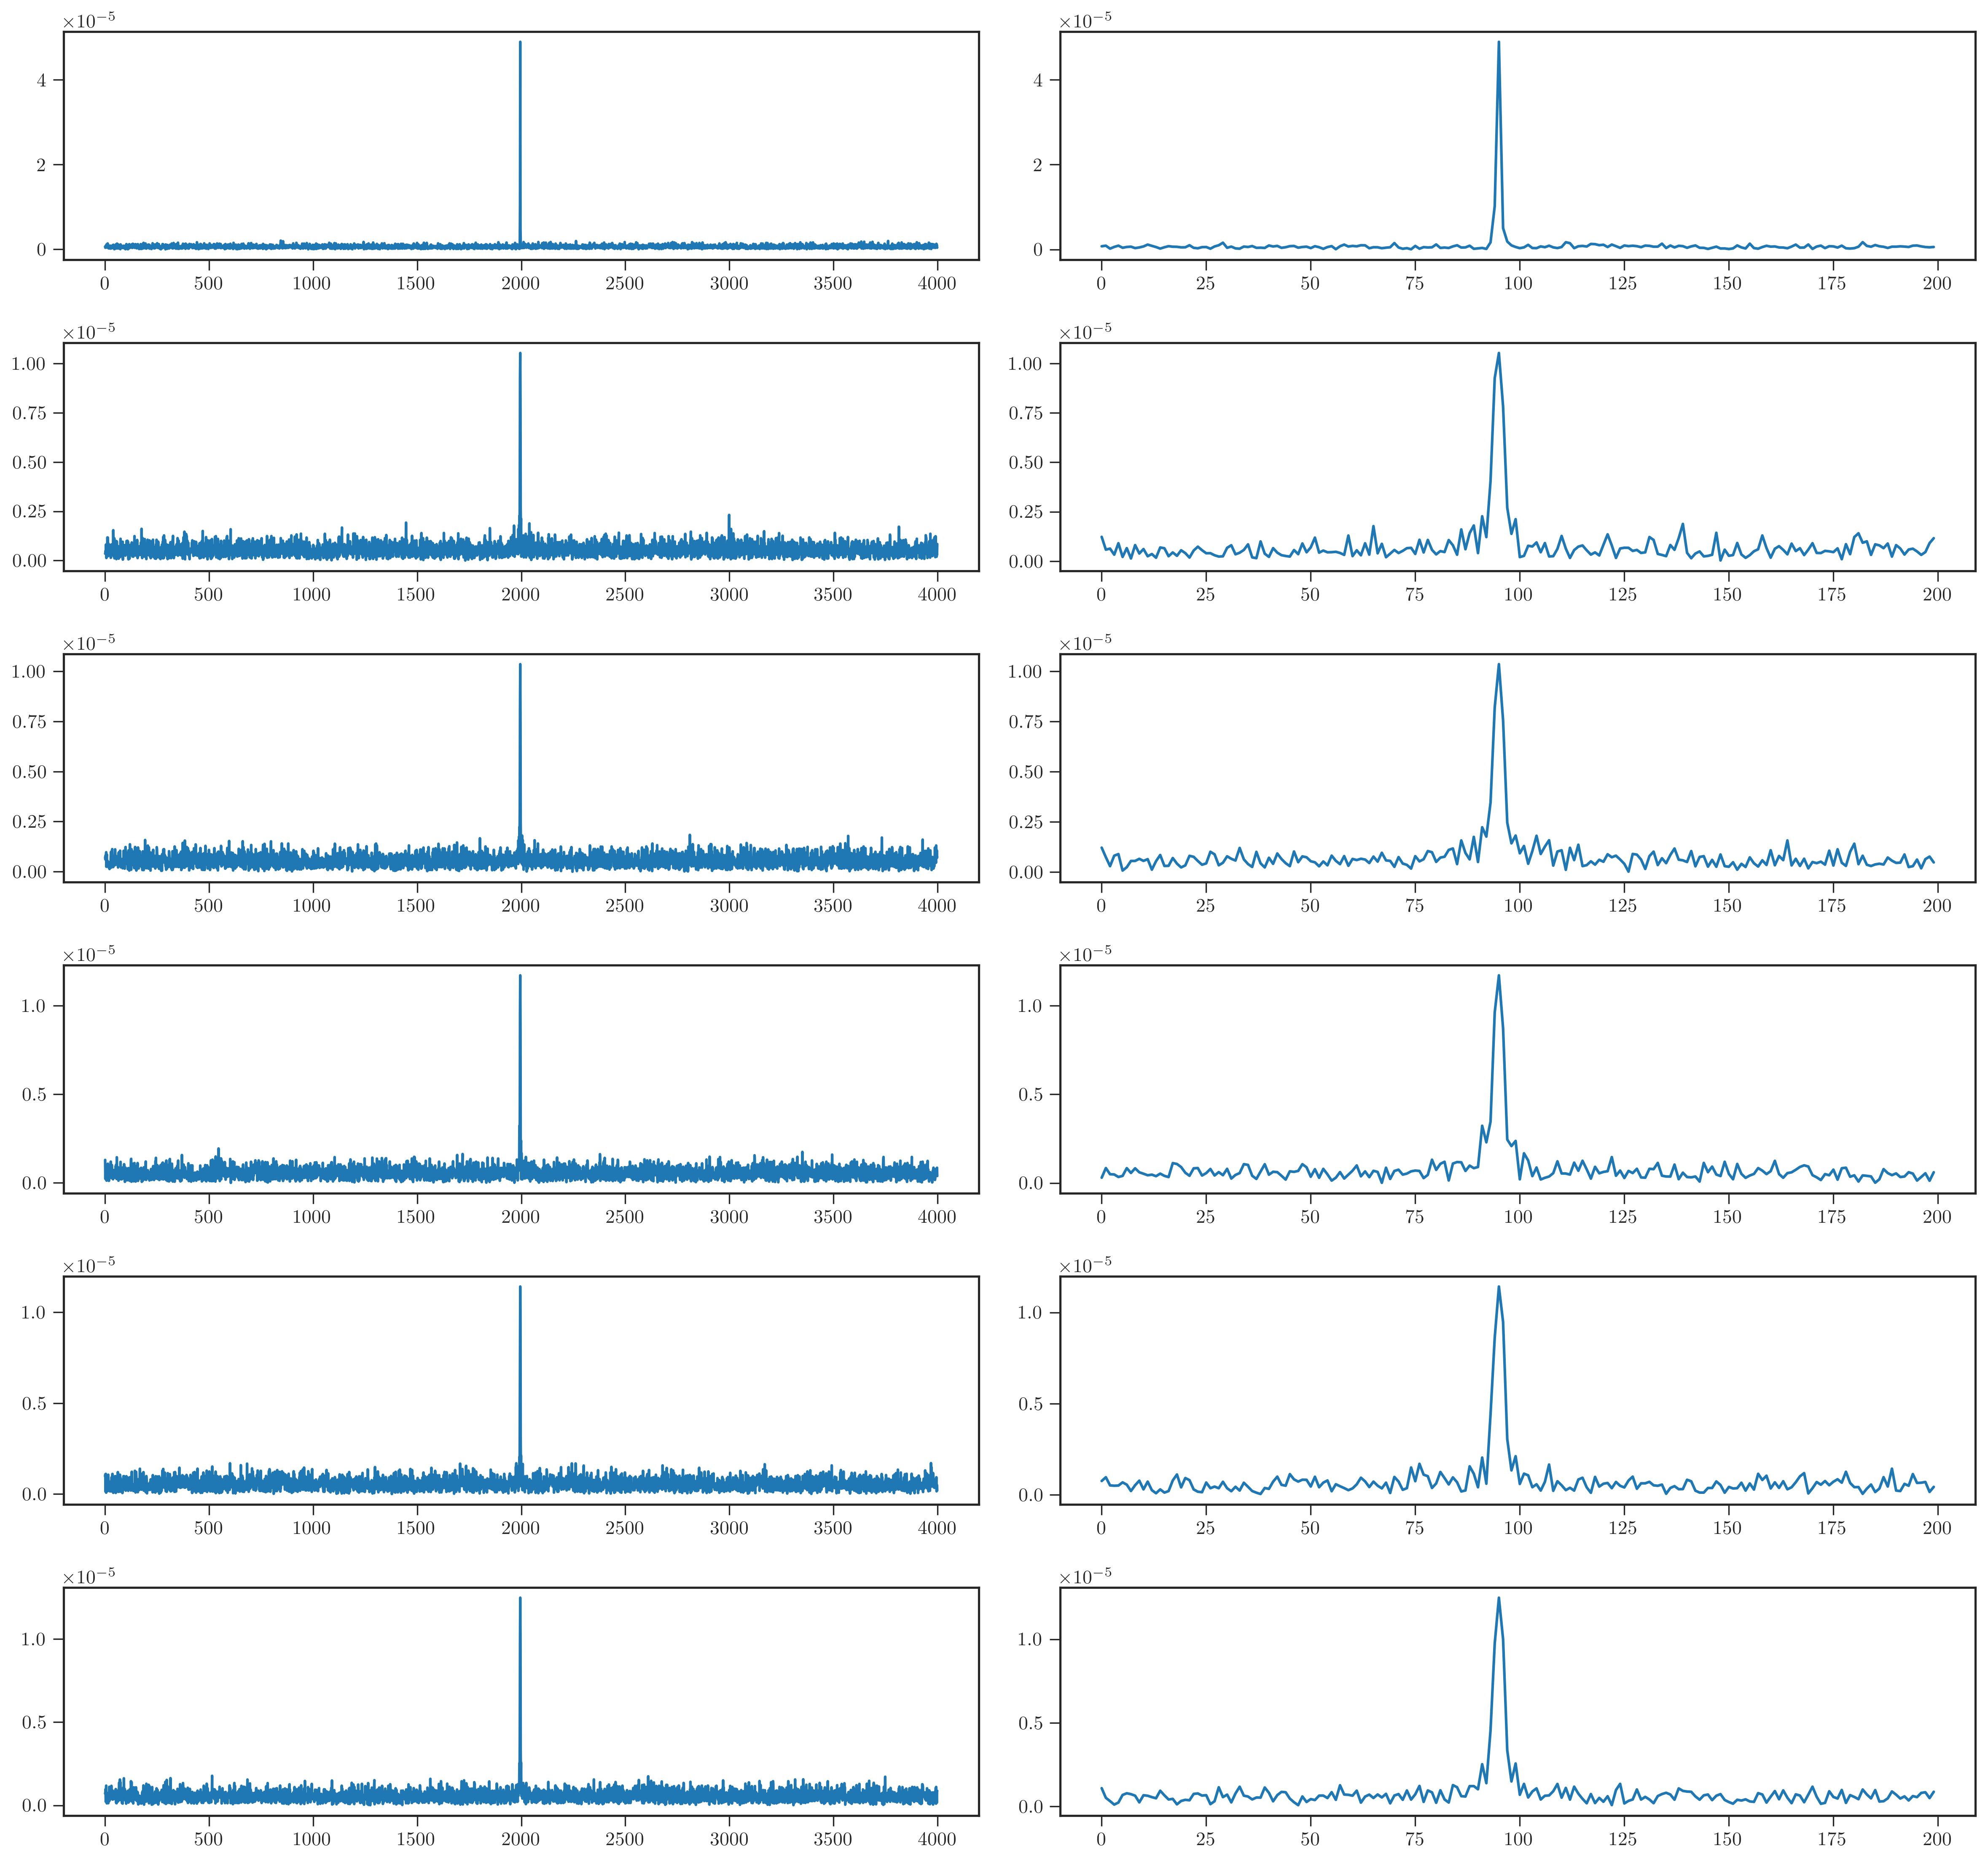

In [14]:
#Plotting the cxcorr
nplots = len(chan_slice)

fig, ax = plt.subplots(nplots, 2, figsize=(16,15))
for i in range(nplots):
    N = cxcorr.shape[1]
    dN=2000
    stamp1 = slice(N//2-dN,N//2+dN)
    stamp2 = slice(N//2-100,N//2+100)
    cx1 = np.abs(cxcorr[i,stamp1])
    cx2 = np.abs(cxcorr[i,stamp2])
    peak = np.argmax(cx1) - dN
    print(peak)
    ax[i, 0].plot(cx1)
    ax[i, 1].plot(cx2)
#plt.axvline(dN-5,c='black')
plt.tight_layout()

In [15]:
#get the SNR
for i in range(nplots):
    noise_real, noise_imag = mad(np.real(cxcorr[i,stamp1])), mad(np.imag(cxcorr[i,stamp1]))
    snr_real = np.max(np.abs(np.real(cxcorr[i,stamp1])))/noise_real
    snr_per_sample = snr_real/np.sqrt(spec1.shape[0])
    print(f'======index {i}')
    print('real snr', snr_real)
    print('in dB', 10*np.log10(snr_real))
    print('per sample snr', snr_per_sample)

======index 0
real snr 39.81870457394416
in dB 16.00087126973682
per sample snr 0.011494669902274423
======index 1
real snr 30.055824252298674
in dB 14.779286425796812
per sample snr 0.008676369111390362
======index 2
real snr 29.99503683001083
in dB 14.770493995310385
per sample snr 0.008658821294079746
======index 3
real snr 34.39675678678156
in dB 15.365174955946308
per sample snr 0.00992948839504921
======index 4
real snr 37.44960010638564
in dB 15.7344718458509
per sample snr 0.010810768351232793
======index 5
real snr 41.148811730428584
in dB 16.14357298445761
per sample snr 0.011878638764698086


## Get the vis

In [16]:
#get the visibilities with and without alignment

#acclen
blocksize = 4096
#total size of data
nblocks = spec1.shape[0]//blocksize
vis_uncorr = np.zeros((nblocks, spec1.shape[1]), dtype="complex128")
vis_corr = np.zeros((nblocks, spec1.shape[1]), dtype="complex128")

shift=5
print("nblocks",nblocks)
print('getting corrected vis')
for i in range(nblocks):
    ix = i * blocksize
    y1 = spec1[ix : ix + blocksize, :]
    y2 = spec2[ix + shift : ix + shift + blocksize, :]
    xc_small = y1 * np.conj(y2)
    vis_corr[i, :] = np.mean(xc_small, axis=0)
phase_corr = np.angle(vis_corr)

print('getting uncorrected vis')
for i in range(nblocks):
    ix = i * blocksize
    y1 = spec1[ix : ix + blocksize, :]
    y2 = spec2[ix : ix + blocksize, :]
    xc_small = y1 * np.conj(y2)
    vis_uncorr[i, :] = np.mean(xc_small, axis=0)
phase_uncorr = np.angle(vis_uncorr)

nblocks 2929
getting corrected vis
getting uncorrected vis


In [17]:
print(phase_corr.shape)

(2929, 60)


In [18]:
freqs_bb = np.arange(1830, 1890)*250e6/4096
min_freq_bb = freqs_bb[0]/1e6
max_freq_bb = freqs_bb[-1]/1e6
nspec = len(phase_corr[:,0])

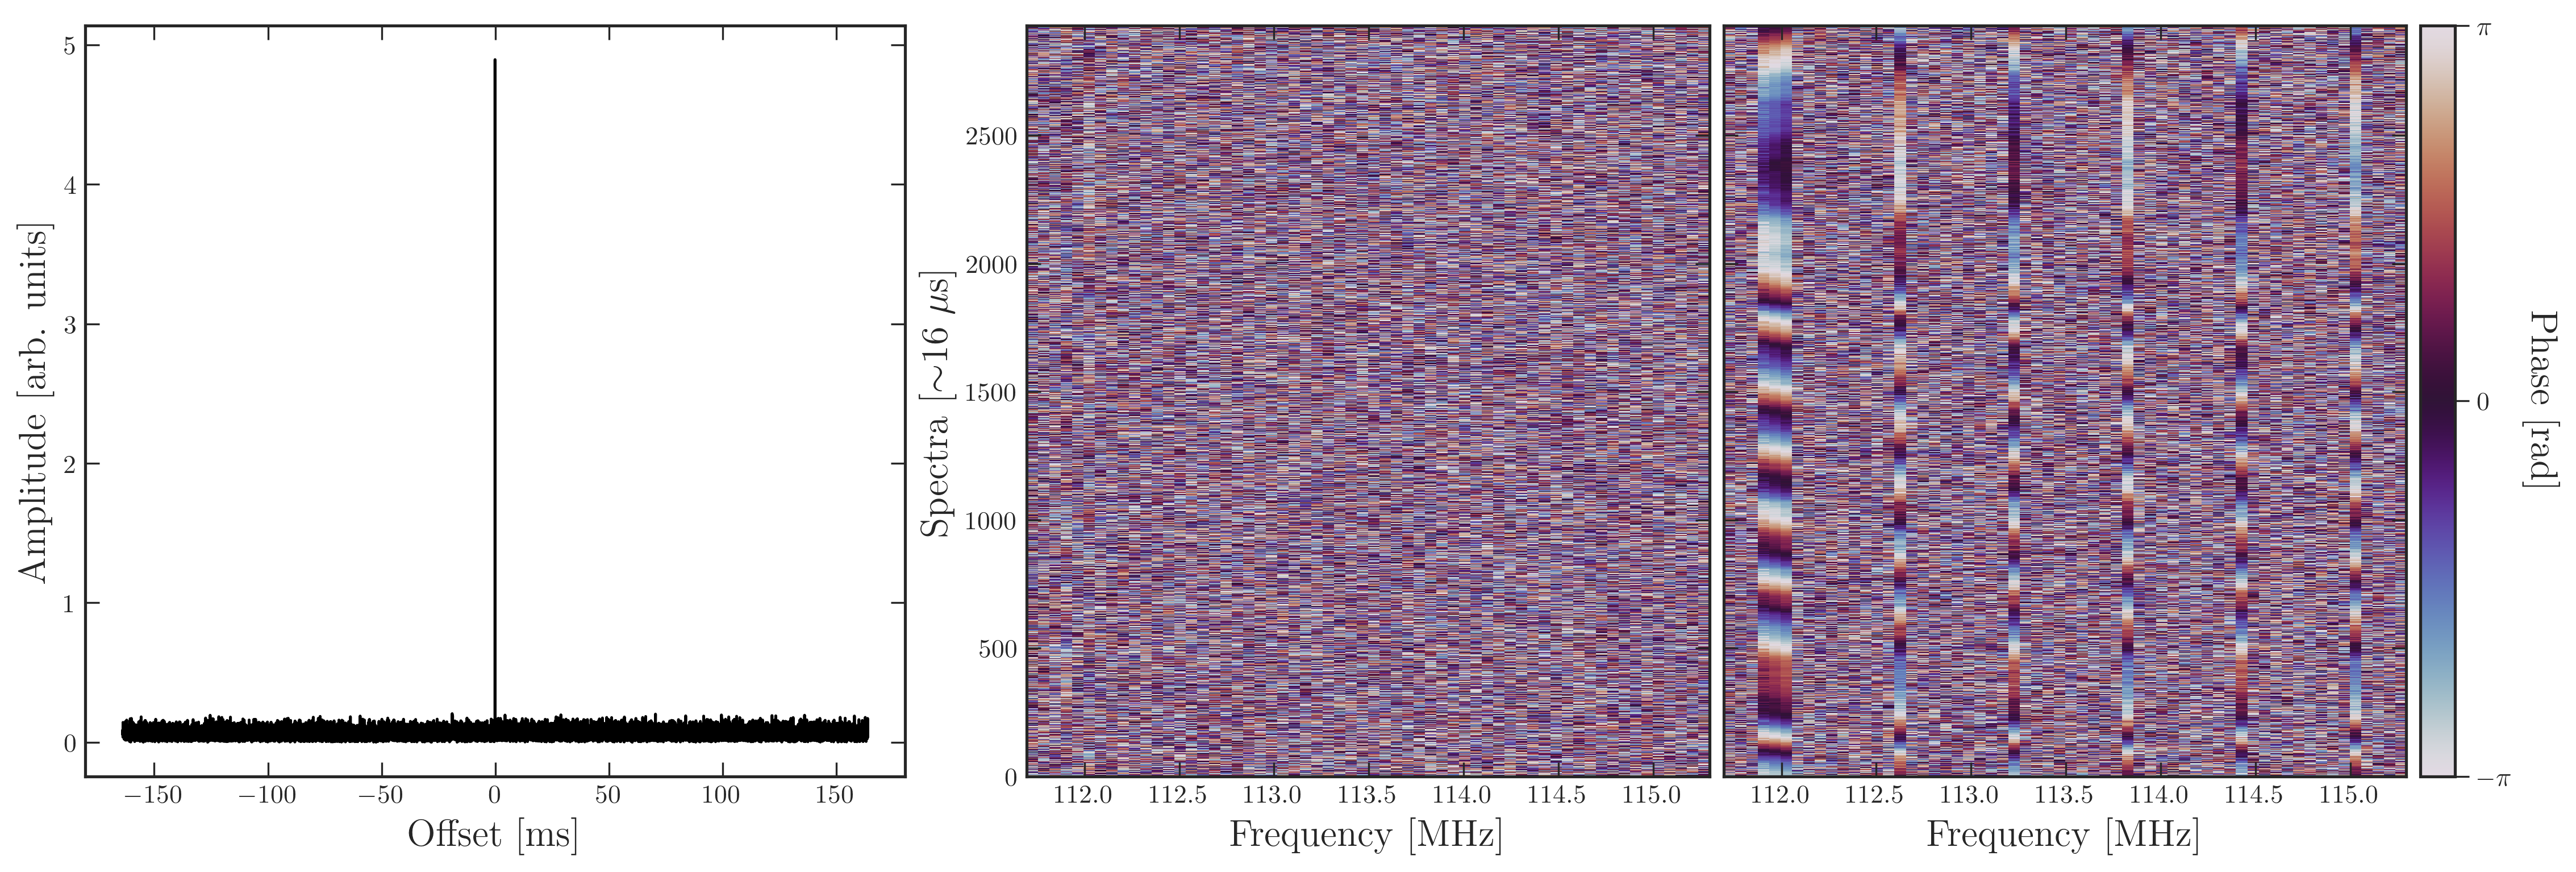

In [19]:
# Correlation window
N = cxcorr.shape[1]
dN = 10000 
T_SPECTRA = 4096 / 250e6

stamp = slice(N // 2 - dN, N // 2 + dN)
cx = np.abs(cxcorr[0, stamp])

# Common phase scale
vmin = -np.pi
vmax = np.pi

fig = plt.figure(figsize=(15, 5), constrained_layout=True)

# Layout: [cxcorr | phase_uncorr | phase_corr | colorbar]
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1.2, 1, 1, 0.05]
)

ax_cx   = fig.add_subplot(gs[0])
ax_unc  = fig.add_subplot(gs[1])
ax_corr = fig.add_subplot(gs[2], sharey=ax_unc)
cax     = fig.add_subplot(gs[3])

#left
ax_cx.plot(np.arange(-dN, dN) * T_SPECTRA * 1e3,np.abs(cx) * 1e5,color='k',lw=1.2)
#ax_cx.set_title(rf"Cross-correlation (Peak = {peak})")
#ax_cx.set_title(rf"Cross-correlation (Wide Band)")
ax_cx.set_xlabel(r"Offset [ms]")
ax_cx.set_ylabel(r"Amplitude [arb. units]")

#middle
im = ax_unc.imshow(phase_uncorr, 
                    aspect='auto',
                    cmap='twilight',
                    interpolation='nearest',
                    origin='lower',
                    vmin=vmin,
                    vmax=vmax, 
                    extent=[min_freq_bb, max_freq_bb, 0, nspec])
#ax_unc.set_title(r"Without Alignment")
ax_unc.set_xlabel(r"Frequency [MHz]")
ax_unc.set_ylabel(r"Spectra [$\sim$16 $\mu$s]")

#right
im = ax_corr.imshow(phase_corr,
                    aspect='auto',
                    cmap='twilight',
                    interpolation='nearest',
                    origin='lower',
                    vmin=vmin,
                    vmax=vmax, 
                    extent=[min_freq_bb, max_freq_bb, 0, nspec])
#ax_corr.set_title(r"With Alignment")
ax_corr.set_xlabel(r"Frequency [MHz]")
ax_corr.tick_params(labelleft=False)

#colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Phase [rad]",rotation=270,labelpad=20)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$",r"$0$",r"$\pi$"])

#ticks
for a in [ax_cx, ax_unc, ax_corr]:
    a.tick_params(direction='in',top=True,right=True)

plt.savefig("/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/sim_cxcorr.png", bbox_inches="tight", dpi=300)
plt.show()

# Upchannelized Data

In [23]:
path1 = "/scratch/mohanagr/raw_64_117260_117516_0.08_20260410_133544.npz"
path2 = "/scratch/thomasb/mohan/repfb_pfbsz65536_cuts64_osamp64_filt0.05_chans1830_1890_nrows187392.npz"
with np.load(path2) as f:
        print(f.keys())
        baseband = f["baseband"]
        delays = f["delays"]
        channels = f["channels"]

KeysView(NpzFile '/scratch/thomasb/mohan/repfb_pfbsz65536_cuts64_osamp64_filt0.05_chans1830_1890_nrows187392.npz' with keys: baseband, delays, channels)


In [33]:
osamp = 64
osampchans = channels
osampspec1 = baseband[0,0,:,:]
osampspec2 = baseband[0,1,:,:]
print(spec1.shape)
print(spec2.shape)
print(osampchans.shape)

(187392, 3840)
(187392, 3840)
(3840,)


In [34]:
print(osampchans[0]/osamp, osampchans[-1]/osamp)

1830.0 1889.984375


In [35]:
#getting the frequencies right
osampfreqs = osampchans/osamp * 250e6/4096
print(osampfreqs[0]/1e6)

111.6943359375


In [36]:
#make visibilities
acclen = 1024

nspec, nchans = osampspec1.shape
osampvis = get_vis(osampspec1, osampspec2, nspec, nchans, acclen)

nblocks 183


In [51]:
250e6/4096/64 * 30

28610.2294921875

In [74]:
print(1845*64 - osampchans[0])
print(1855*64 - osampchans[0])
print(1865*64 - osampchans[0])
print(1875*64 - osampchans[0])
print(1885*64 - osampchans[0])

s1, e1 = 938, 962
s2, e2 = 1593, 1617
s3, e3 = 2222, 2246
s4, e4 = 2877, 2901
s5, e5 = 3507, 3531

960
1600
2240
2880
3520


In [77]:
windows = [(s1, e1),(s2, e2),(s3, e3),(s4, e4),(s5, e5)]

vis2_wdw = np.concatenate([osampvis[:, s:e] for s, e in windows], axis = 1)
print(vis2_wdw.shape)

(183, 120)


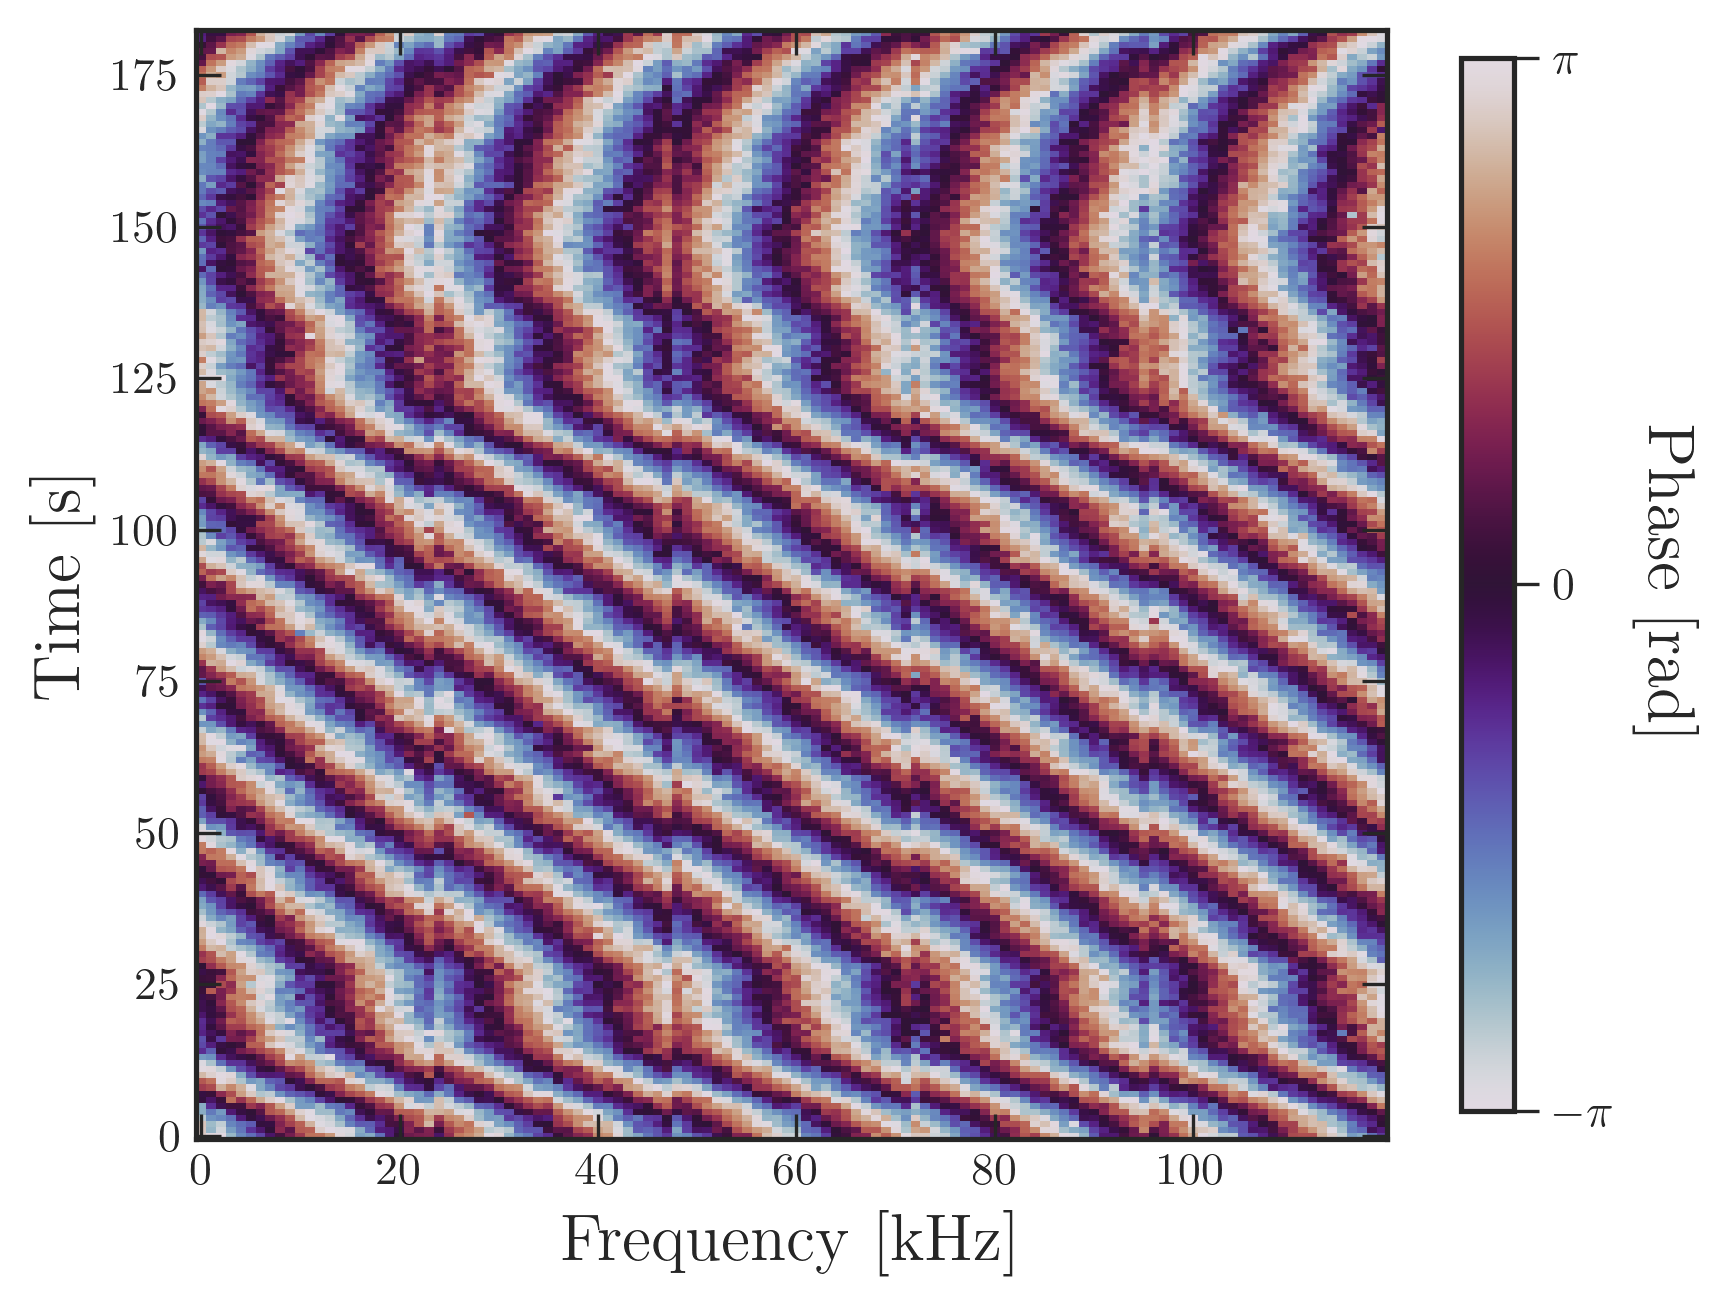

In [78]:
# Phase data
data = np.angle(osampvis[:, s5:e5])
data = np.angle(vis2_wdw)

vmin, vmax = -np.pi, np.pi

# Create side-by-side figure
fig, ax = plt.subplots()

#left
im = ax.imshow(data,aspect='auto',cmap='twilight',interpolation='nearest',origin='lower',vmin=vmin,vmax=vmax)
#ax.set_title(r"Dataset 1")
ax.set_ylabel(r"Time [s]")
ax.set_xlabel(r"Frequency [kHz]")

# Publication-style ticks
ax.tick_params(direction='in', top=True, right=True)

#colorbar
cbar = fig.colorbar(im,ax=ax,location='right',shrink=0.95)
cbar.set_label(r"Phase [rad]",rotation=270,labelpad=20)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$",r"$0$",r"$\pi$"])
#plt.show()

In [40]:
np.savez("/scratch/thomasb/sim_finetiming/osampvis_v2.npz",vis=osampvis,chans=osampchans)

# Fine Timing

In [33]:
d = np.load('/scratch/thomasb/sim_finetiming/delay_results.npz')
tau_s = -d['taus_small']
tau_0 = -d['net']
errs = d['errs'] 

In [34]:
#set global variables
osamp = 64
acclen = 1024
nspec = len(delays)
nvis = len(tau_s)

#get tau data
tau_all = tau_0 + tau_s

print('total vis', nvis)
print('total spectra from vis', nvis*osamp*acclen)
print('total samples in delay', nspec)
print(f'coverage: {(nvis*osamp*acclen/nspec *100):.3f}%')

total vis 183
total spectra from vis 11993088
total samples in delay 12000000
coverage: 99.942%


In [35]:
freq_slice = slice(70, 170)
nfreqs_osamp = 100
min_freq_osamp = osampfreqs[70]/1e6
max_freq_osamp = osampfreqs[170]/1e6
nvis = len(osampvis[:,0])

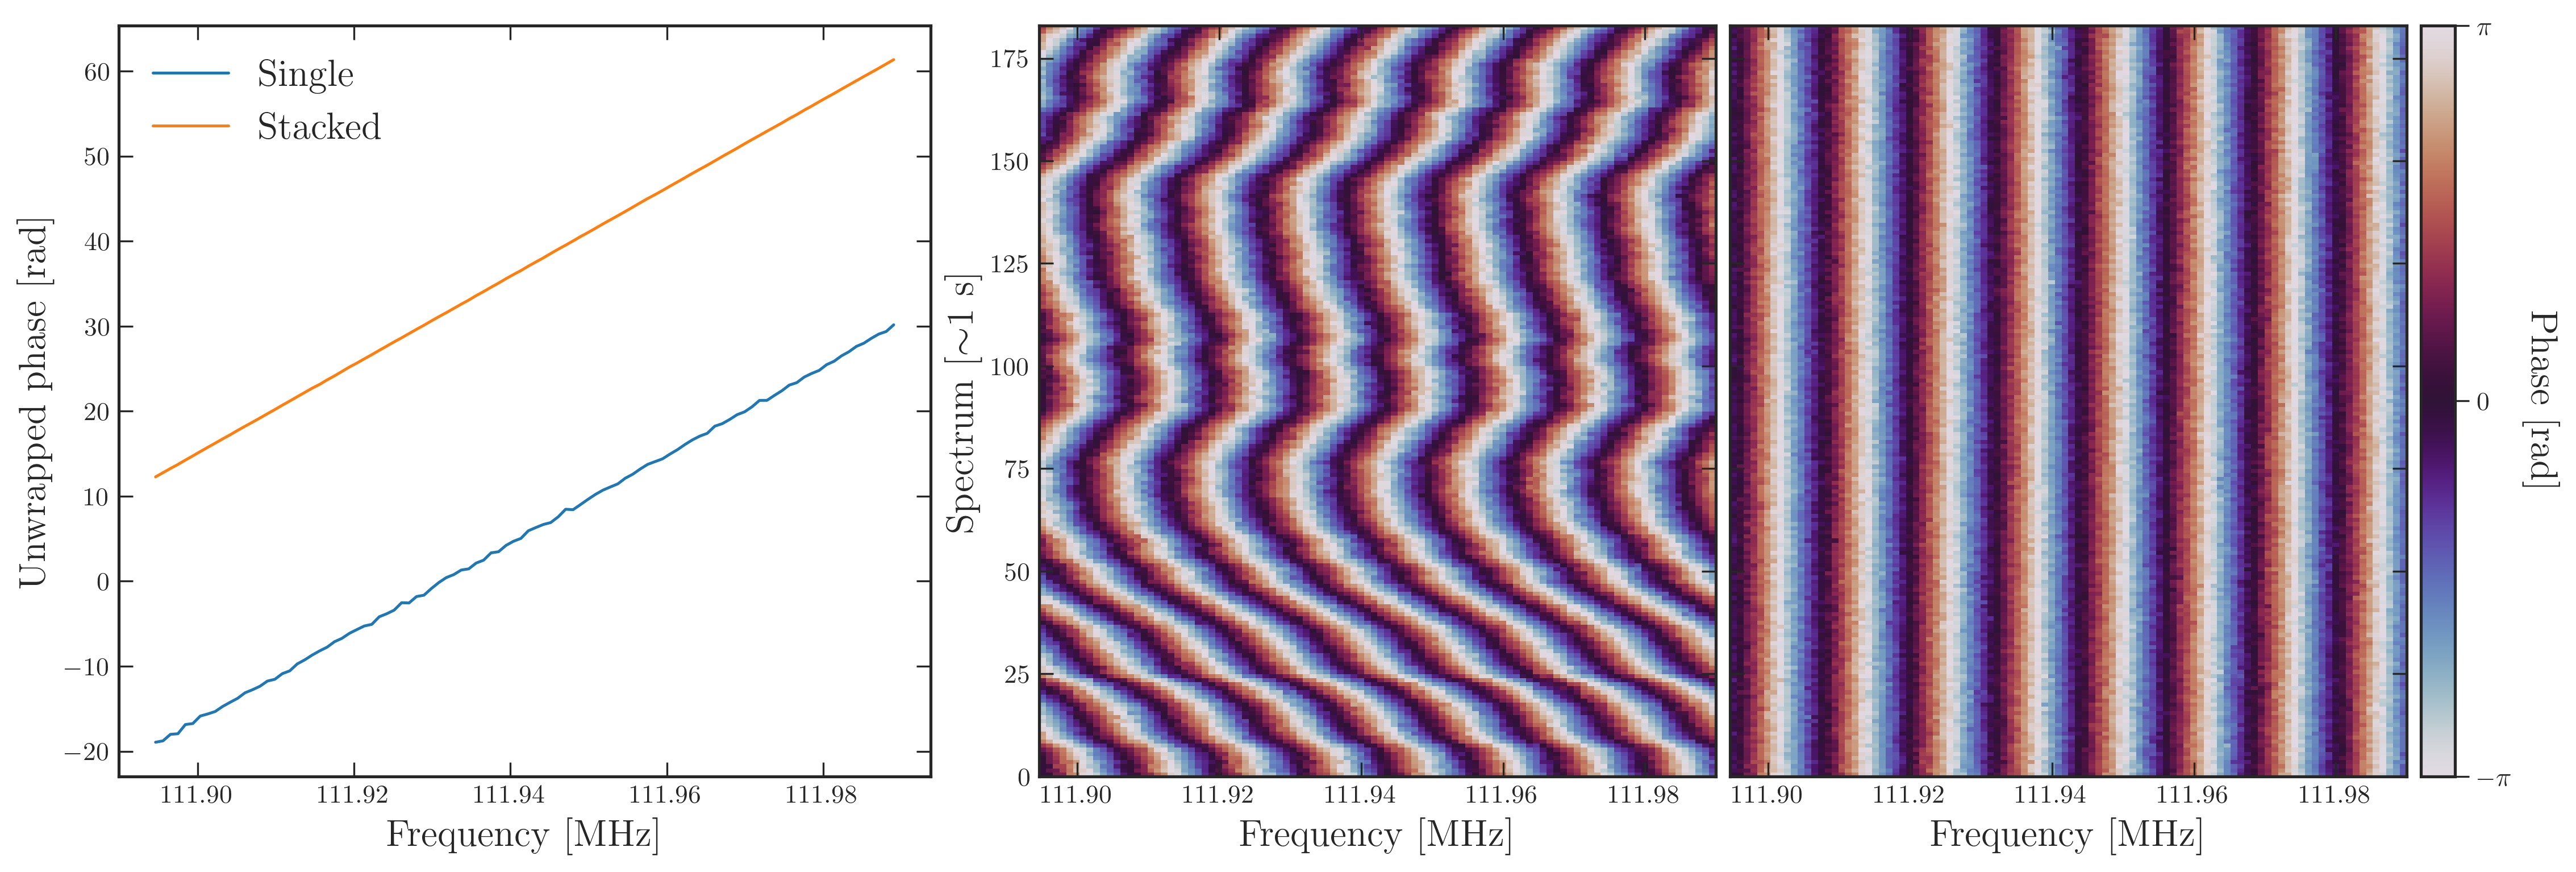

In [36]:
# Get aligned visibilities
phased_vis = osampvis * np.exp(-2j*np.pi*osampfreqs[None, :]/1e9*tau_s)

# Get ramps
ramp_stacked = np.unwrap(np.angle(np.mean(phased_vis, axis=0)))
ramp_single  = np.unwrap(np.angle(osampvis[0, :]))

# Common phase scale
vmin = -np.pi
vmax = np.pi

# Figure
fig = plt.figure(figsize=(15, 5), constrained_layout=True)

# EXACT SAME LAYOUT AS OLD FIGURE
gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 0.05])

ax_ramps = fig.add_subplot(gs[0])
ax_unc   = fig.add_subplot(gs[1])
ax_corr  = fig.add_subplot(gs[2], sharey=ax_unc)
cax      = fig.add_subplot(gs[3])

# Left: phase ramps

ax_ramps.plot(osampfreqs[freq_slice]/1e6, ramp_single[freq_slice], lw=1.2, label="Single")

ax_ramps.plot(osampfreqs[freq_slice]/1e6,ramp_stacked[freq_slice],lw=1.2,label="Stacked")

ax_ramps.set_xlabel("Frequency [MHz]")
ax_ramps.set_ylabel("Unwrapped phase [rad]")
ax_ramps.legend(frameon=False)

# Middle: uncorrected

im = ax_unc.imshow(
    np.angle(osampvis[:, freq_slice]),
    extent=[min_freq_osamp, max_freq_osamp, 0, nvis],
    aspect='auto',
    cmap='twilight',
    interpolation='nearest',
    origin='lower',
    vmin=vmin,
    vmax=vmax
)

ax_unc.set_xlabel("Frequency [MHz]")
ax_unc.set_ylabel(r"Spectrum [$\sim$1 s]")

# Right: corrected

ax_corr.imshow(
    np.angle(phased_vis[:, freq_slice]),
    extent=[min_freq_osamp, max_freq_osamp, 0, nvis],
    aspect='auto',
    cmap='twilight',
    interpolation='nearest',
    origin='lower',
    vmin=vmin,
    vmax=vmax
)

ax_corr.set_xlabel("Frequency [MHz]")
ax_corr.tick_params(labelleft=False)

# Colorbar

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(
    r"Phase [rad]",
    rotation=270,
    labelpad=20
)

cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

# Ticks

for ax in [ax_ramps, ax_unc, ax_corr]:
    ax.tick_params(direction='in', top=True, right=True)

plt.savefig(
    "/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/sim_alignment.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [37]:
# fit for each time downsampled

noise_matrix_avg = np.zeros((nvis, 1),dtype='float64')
x = osampfreqs[freq_slice]
avg_multi_phase =  np.unwrap(np.angle(osampvis[:, freq_slice]), axis=1)

print('freqs', x.shape)
print('avg multi phase', avg_multi_phase.shape)

for i in range(nvis):
    y = avg_multi_phase[i,:]
    m, c = np.polyfit(x, y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[i] = np.std(residual)

print('noise matrix', noise_matrix_avg.shape)
print('some entry', noise_matrix_avg[0])

freqs (100,)
avg multi phase (183, 100)
noise matrix (183, 1)
some entry [0.1496551]


In [38]:
print(noise_matrix_avg[0].shape)

(1,)


In [84]:
#fit onto the guess ramp using normal equations

ts = np.zeros(nvis)
print(nvis)

data_matrix = avg_multi_phase.reshape(nvis, nfreqs_osamp, 1)
freqs_normalized = osampfreqs[freq_slice]/1e9
nant = 2
#============

Ag = get_grammian(nant)
AtA,Atd = get_AtA_Atd(data_matrix,
                        Ag,
                        noise_matrix_avg**2,
                        freqs_normalized,
                        nant,
                        nfreqs_osamp,  
                        nvis,
                        fit_constant = True
                        )

AtA_inv = np.linalg.inv(AtA)
fit = AtA_inv @ Atd
#print(fit)

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
print(bs, 'Baselines')
tau_downsample = fit[:nvis]
print('taus:', tau_downsample[:10])
phi_downsample = fit[nvis:]
print('phis:', phi_downsample[:3])

errs = np.sqrt(np.diag(AtA_inv))
errs_tau = errs[:nvis]
print('taus errs', errs_tau[:3])
errs_phi = errs[nvis:]
print('phi errs', errs_phi[:3])

183
n pertime 100
Snu 70.33511636391509 Snu2 49.470288931073185
1 Baselines
taus: [-82742.29496753 -82742.61057776 -82742.77911955 -82742.77315378
 -82743.07736778 -82743.20373893 -82743.56143486 -82744.36414927
 -82745.35943806 -82746.01393509]
phis: [58172.65262526]
taus errs [5.91051986 5.91051425 5.91052088]
phi errs [4.15714434]


In [85]:
print(tau_downsample.shape)

(183,)


In [86]:
tau_downsample = -tau_downsample

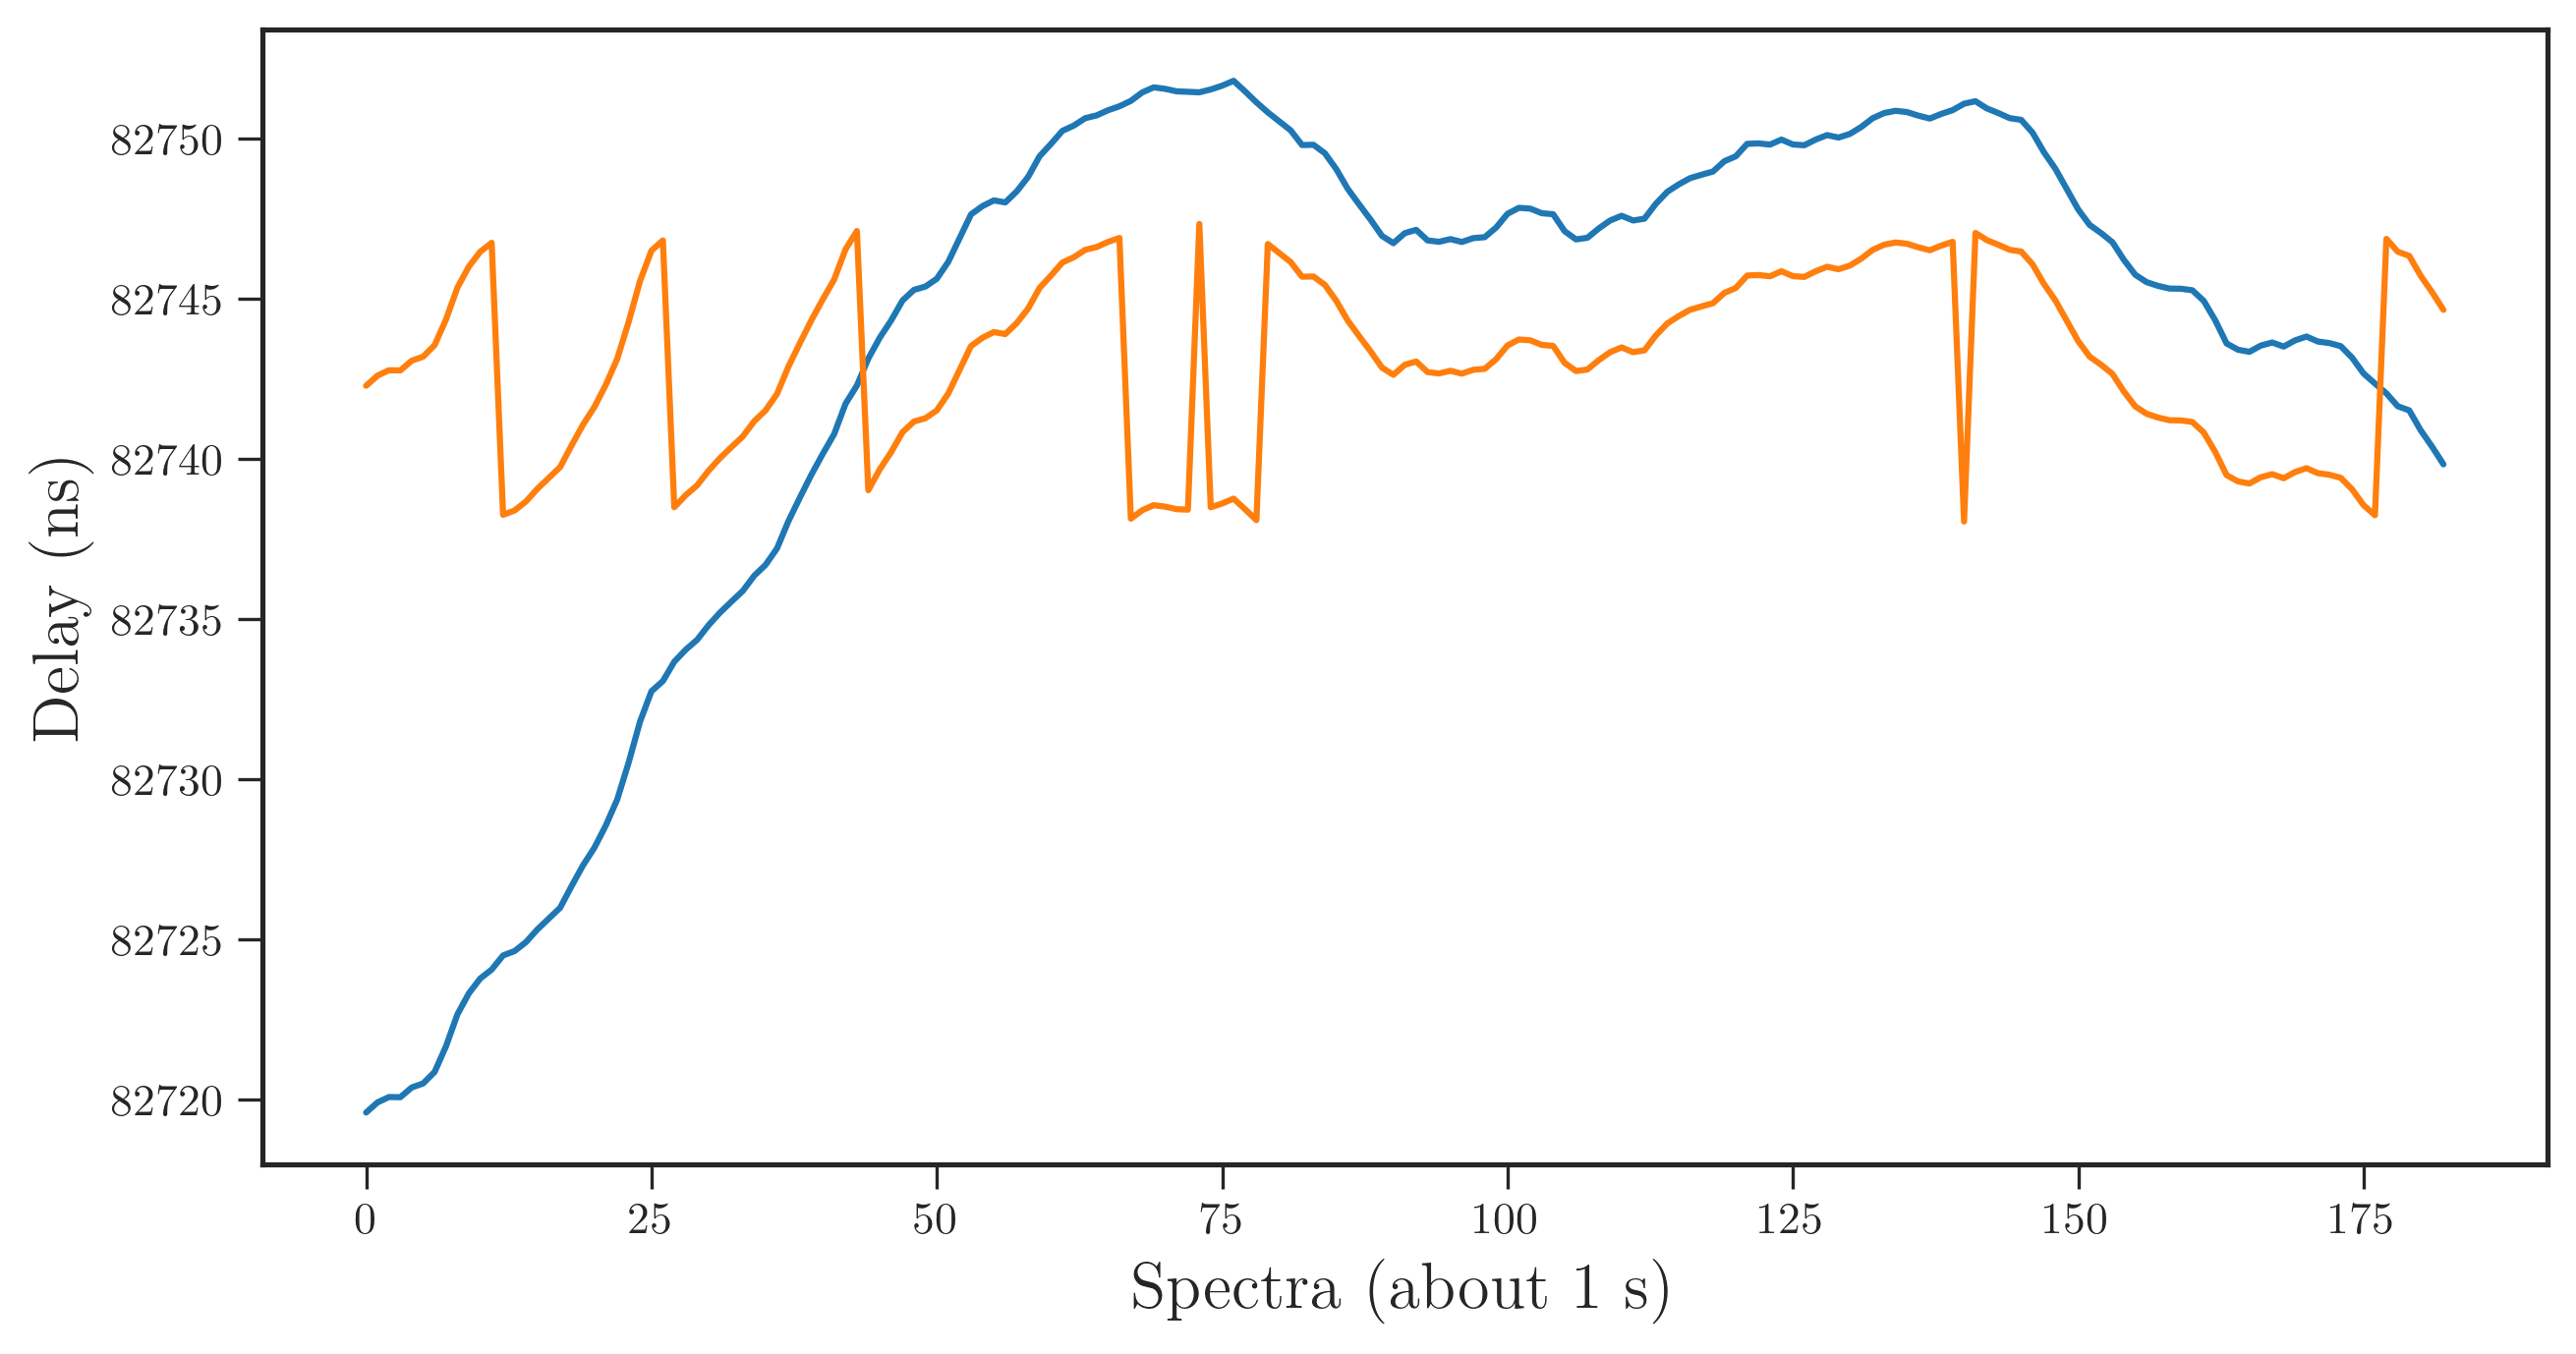

In [87]:
plt.figure(figsize=(10,5))
plt.plot(tau_all, label='actual taus')
plt.plot(tau_downsample, label='indep downsample fits')
plt.ylabel('Delay (ns)')
plt.xlabel('Spectra (about 1 s)')
plt.show()


In [53]:
#define the taus
good_taus = tau_all
bad_taus = np.unwrap(tau_downsample)
print(good_taus.shape, bad_taus.shape)

#the baseband spectra that correspond to the timing solution are in the CENTER of the acclen
spectra = np.arange(0.5, nvis+0.5)*osamp*acclen
print('spectra', spectra[:3])
print('spectra shape', spectra.shape)

#want to find where these start and stop so we can interpolate between places we actually have data
start = int(spectra[0])
end = int(spectra[-1])
print('start and end', start, end)

delays = np.asarray(delays).squeeze().astype(float)
spectra = np.asarray(spectra).squeeze().astype(float)
good_taus = np.asarray(good_taus).squeeze().astype(float)
bad_taus = np.asarray(bad_taus).squeeze().astype(float)

y1 = (delays[start:end]) + 82720
y1 = y1[::10]
print('y1', y1[:3])

y2_interp = np.interp(np.arange(start, end, 10), spectra, good_taus)
print('y2', y2_interp[:3])
y3_interp = np.interp(np.arange(start, end, 10), spectra, bad_taus)
print('y3', y3_interp[:3])

res_good = y1 - y2_interp
res_bad = y1 - y3_interp

print('good res', res_good[:3])
print('bad res', res_bad[:3])

res_plot_good = res_good - np.mean(res_good)
res_plot_bad = res_bad - np.mean(res_bad)

print('good plot res', res_plot_good)
print('bad plot res', res_plot_bad)

(183, 1) (183,)
spectra [ 32768.  98304. 163840.]
spectra shape (183,)
start and end 32768 11960320
y1 [82720.24809219 82720.24816757 82720.24819218]
y2 [82719.60582149 82719.60586964 82719.6059178 ]
y3 [82790.19382834 82790.19418343 82790.19453851]
good res [0.6422707  0.64229793 0.64227438]
bad res [-69.94573615 -69.94601585 -69.94634633]
good plot res [-0.0165991  -0.01657188 -0.01659542 ... -0.02009203 -0.02010224
 -0.0200909 ]
bad plot res [-29.65879382 -29.65907353 -29.659404   ...  -2.02410375  -2.02421686
  -2.02430842]


/tmp/ipykernel_383748/925100414.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(


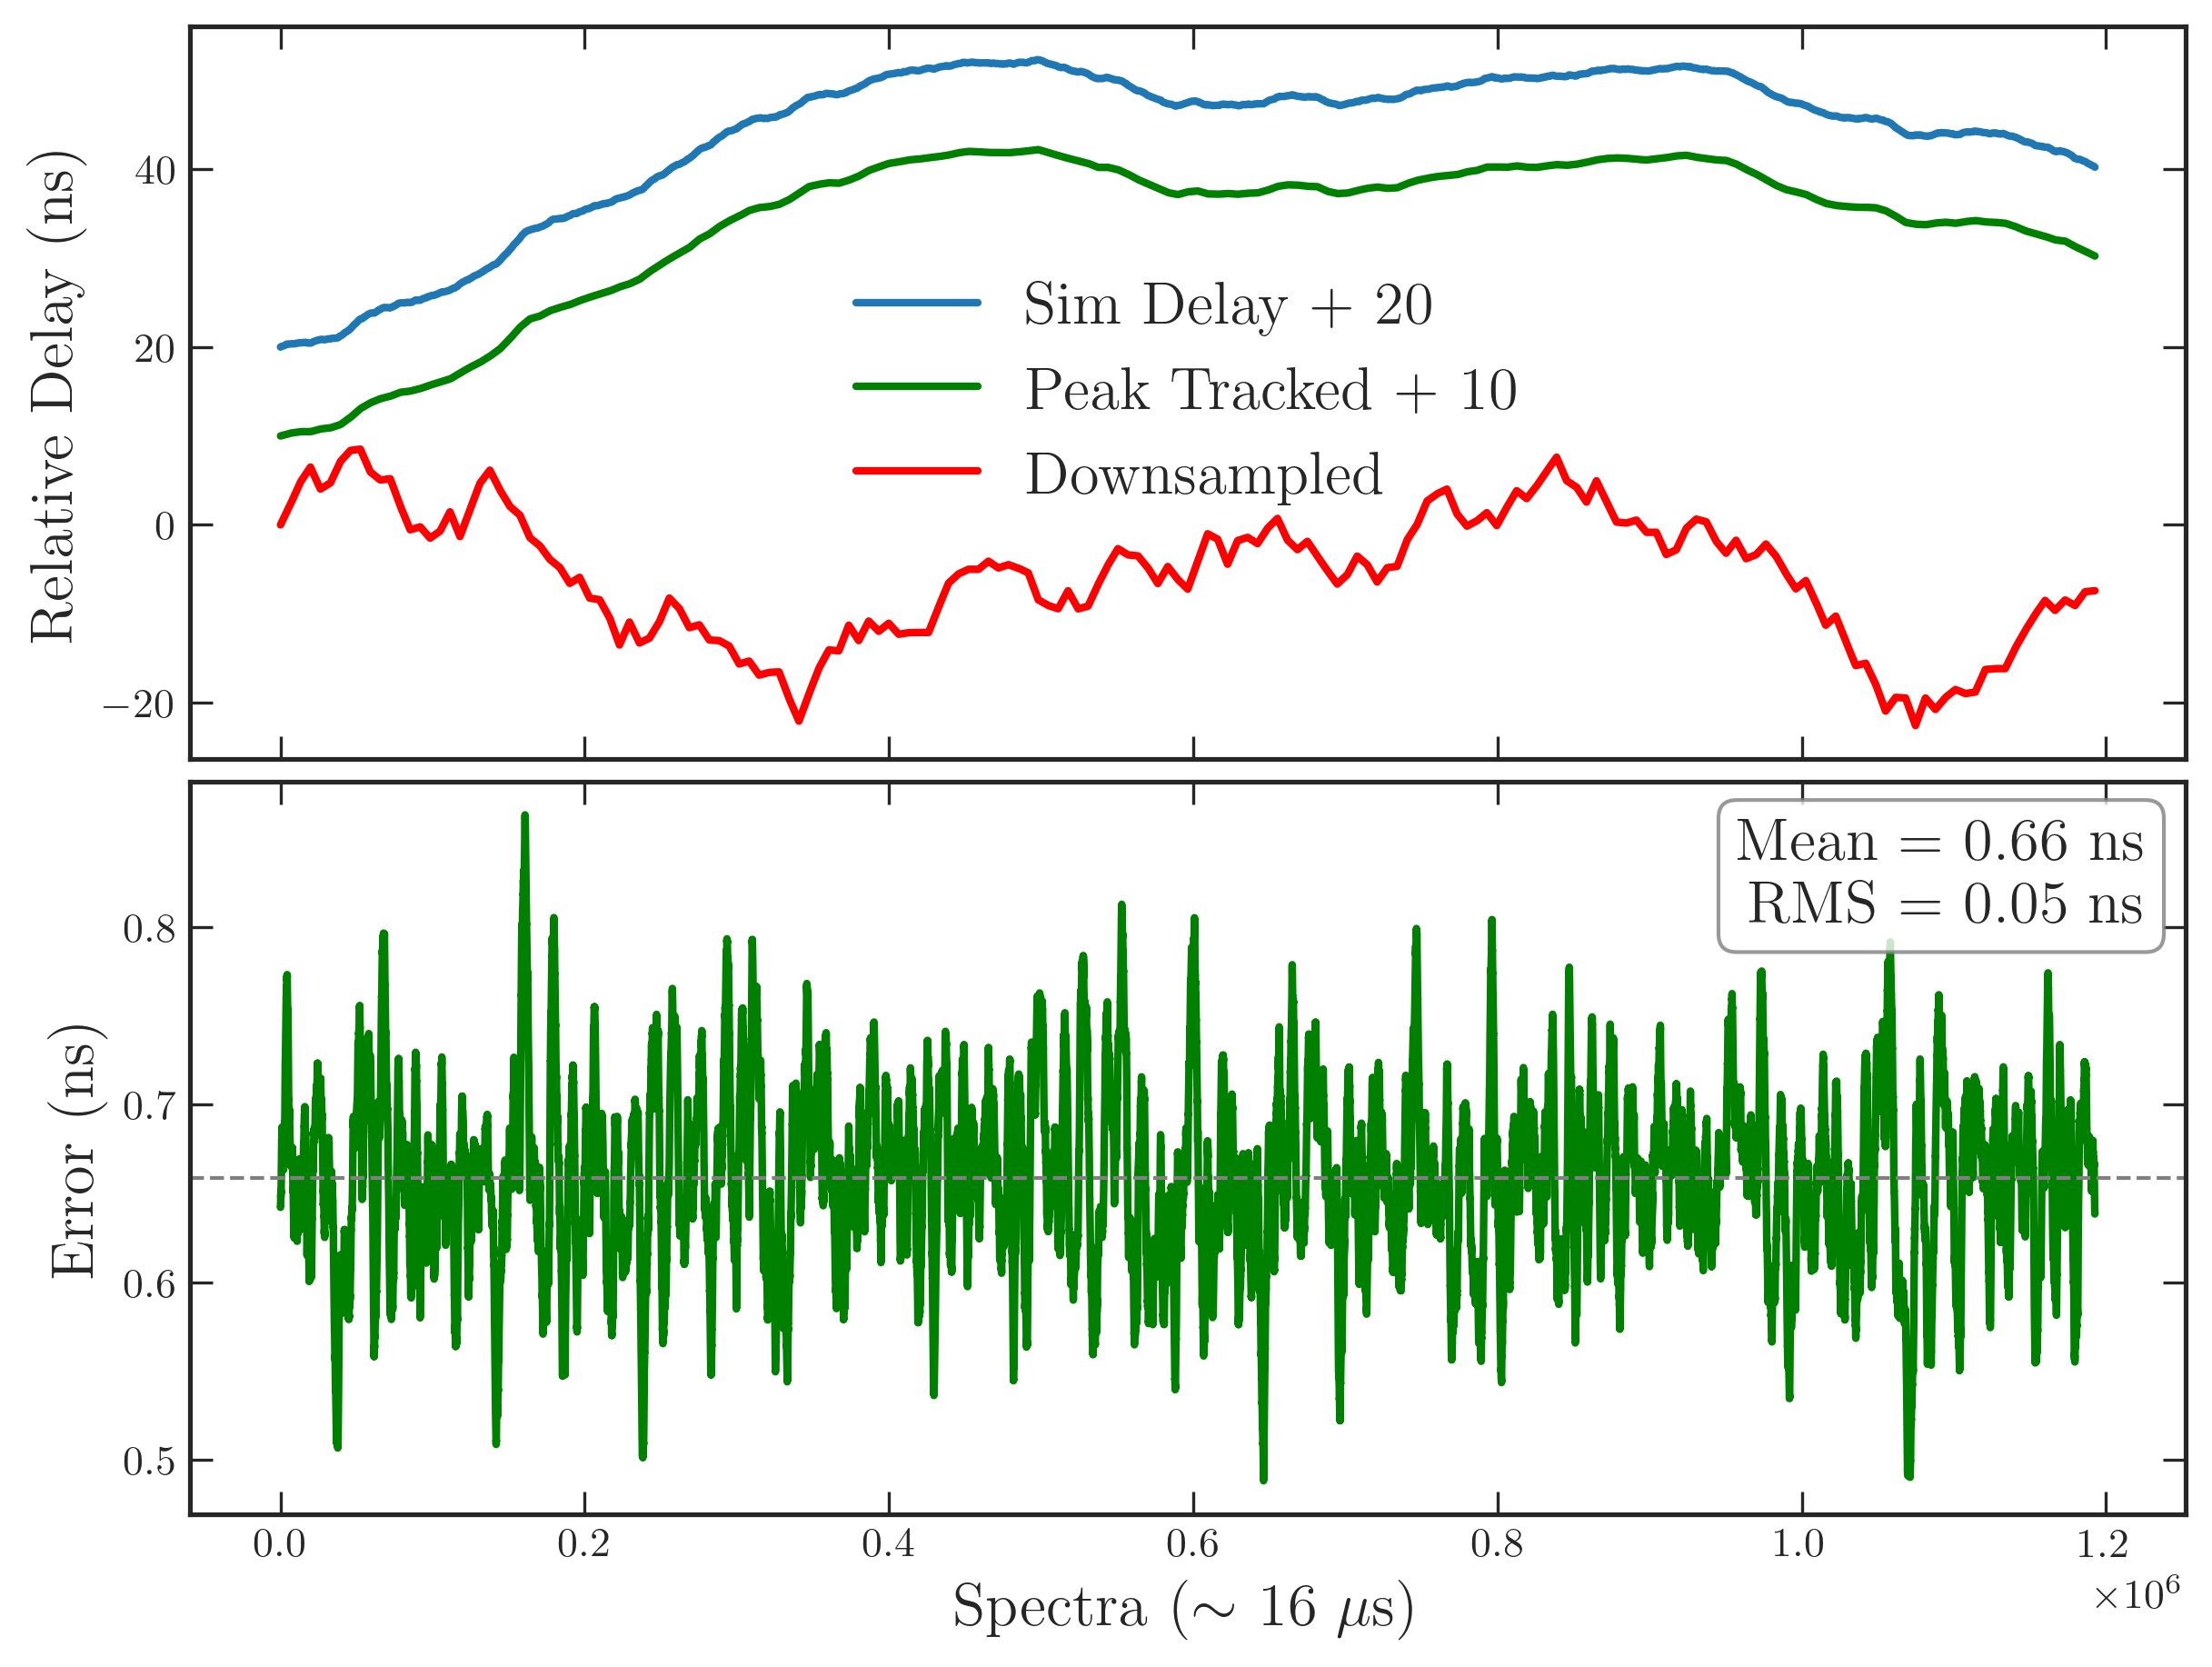

In [60]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    constrained_layout=True
)

# --- delays ---
ax[0].plot(y1 - y1[0] + 20, label="Sim Delay + 20", lw=2)

ax[0].plot(y2_interp - y2_interp[0] + 10, label="Peak Tracked + 10", lw=2, color = 'green')

ax[0].plot(y3_interp - y3_interp[0], label="Downsampled", lw=2, color = 'red')

ax[0].set_ylabel("Relative Delay (ns)")
ax[0].legend(frameon=False)

ax[1].plot(res_good, label="Peak Tracked residual", lw=2, color='green')

#ax[1].plot(res_plot_bad, label="Downsampled residual", lw=2, color='red')

ax[1].axhline(np.mean(res_good), color="gray", ls="--", lw=1)

ax[1].set_xlabel(r"Spectra ($\sim$ 16 $\mu$s)")
ax[1].set_ylabel("Error (ns)")
#ax[1].legend(frameon=False)


ax[1].text(
    0.98, 0.95,
    f"Mean = {np.mean(res_good):.2f} ns\n"
    f"RMS = {np.std(res_good):.2f} ns",
    transform=ax[1].transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray")
)

for a in ax:
    a.tick_params(direction="in", top=True, right=True)

plt.savefig(
    "/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/fitted_taus.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [61]:
print((4096*5 + 200)*4)
print('good res offset', np.mean(res_good))
print('good res std', np.std(res_good))

print('bad res offset', np.mean(res_bad))
print('bad res std', np.std(res_bad))
# print(np.std(res))
print((4096*5 + 200)*4  + np.mean(res_good))

82720
good res offset 0.6588698074965598
good res std 0.05093276046845984
bad res offset -40.28694232782719
bad res std 12.8027466369064
82720.65886980749
